# Rotate / Permute the sequences to match your favorite 'Huge Plasmid'/BAC

When you receive your 'Huge Plasmid' sequence back from Plasmidsaurus you'll likely need to adjust it since as the Blog Post ['Plasmidsaurus fasta standardizer' (Posted on April 6, 2023 by kmatreyek)](https://www.matreyeklab.com/plasmidsaurus-fasta-standardizer/1803/) points out, the start point is rather arbitrary.

You can think of it this way:   
The standard start of a day is the point on a wall clock a second after midnight. With Plasmidsaurus-returned sequeneces, the start of the day chosen is arbitrary, and you need to rotate the  metaphorical wall clock from Plasmidsaurus to set it back to match the convention of the moment after midnight. Then with matching start points, it becomes easier to see how the two relate.

Plasmidsaurus' related information about their processing pipeline is at ['Whole Genome Technical Documentation'](https://plasmidsaurus.com/technical-documentation/genome). 

The idea is that you work through this notebok as-it-is and then next modify it to use yourself with your own sequences.

if you are already running this in an active Jupyter session, skip this next small section and continue where you see 'Determining the start point', just below.

#### Where can I run this notebook without installing anything on my own machine? 
Presently, you can run this notebook in MyBinder-served sessions that include biopython installed.  
I have, though, set up things so that you can launch using the following launch badge and not only will the environment be set up appropriately, all the necessary ancillary files will also be present in the temporary session:

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/fomightez/sequencework/HEAD?urlpath=%2Flab%2Ftree%2Fplasmidsaurus-utilities%2FRotate%20SLASH%20Permute%20the%20sequences%20to%20match%20your%20favorite%20Huge%20Plasmid%20or%20BAC.ipynb)

Please use that badge or [click here to directly launch the recommended session](https://mybinder.org/v2/gh/fomightez/sequencework/HEAD?urlpath=%2Flab%2Ftree%2Fplasmidsaurus-utilities%2FRotate%20SLASH%20Permute%20the%20sequences%20to%20match%20your%20favorite%20Huge%20Plasmid%20or%20BAC.ipynb) to get things going in the easiest way possible.

If you are an advanced user and just want a more basic session with biopython and are comfortbale having to get & place the ancillary in the running session yourself, then here are some additional options where Biopython is installed and working:  
- [my 'cl_demo-binder' here](https://github.com/fomightez/cl_demo-binder)
- (I'm not sure launches from the seemingly more appropriate [repo 'cl_sq_demo-binder'](https://github.com/fomightez/cl_sq_demo-binder) are presently 
failing.)

(Still to explore: Is JupyterLite also an option for running the demo notebook?)

-------------------------

### Determining the start point


First, you need to determine the arbitrary start point in the sequence that you received from Plasmidsaurus.

You can use NCBI's BLAST to do a pairwise alignment of the FASTA-formatted DNA obtained for your plasmidsaurus result against your favorite BAC. (Direct link: [Nucleoditde BLAST here](https://blast.ncbi.nlm.nih.gov/BlastAlign.cgi))   
Toggle 'Align two or more sequences' to bring up the option when you [there](https://blast.ncbi.nlm.nih.gov/Blast.cgi?PROGRAM=blastn&PAGE_TYPE=BlastSearch&LINK_LOC=blasthome).  
You'll want your sequence will be in the first spot.  
With the best standard version of the sequence in the second spot.  
Choose 'Somewhat similar sequences (blastn)' under 'Optimize'.

(If you began this, notebook in the recommended MyBinder session, the sequences for this example are provided here if you want to repeat this step.
The FASTA of the result is stored as `holy_toledo_mock_Plasmidsaurus_result.fa` here.  
The Toledo strain that is use the standard version of the basis for this sequence is `HCMV_Toledo_wild-type.fasta` here.  
If you are an advanced user working through this where you prefer, you can find the files [here](https://github.com/fomightez/sequencework/tree/master/plasmidsaurus-utilities).)

When that BLAST query finishes, then you should see something like this among the top part of one of the aligned sequences among your results:


```text
Range 5: 1 to 2425 
Alignment statistics for match #5
Score	Expect	Identities	Gaps	Strand
4369 bits(4845)	0.0	2424/2425(99%)	0/2425(0%)	Plus/Plus
Query  177897  CCATTCCGGGCCGTGTGCTGGGTCCCCGAggggcgggggggtgtttttagcgggggggTG  177956
               ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
Sbjct  1       CCATTCCGGGCCGTGTGCTGGGTCCCCGAGGGGCGGGGGGGTGTTTTTAGCGGGGGGGTG  60

Query  177957  AAATTTGGAGTCTTGGAGCCGCGTGTGCTGTGGAGGACGGTGACGGTGGTAAGAGTGTGC  178016
               ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
Sbjct  61      AAATTTGGAGTCTTGGAGCCGCGTGTGCTGTGGAGGACGGTGACGGTGGTAAGAGTGTGC  120

Query  178017  TGCGGTGCGGTTGGGACGGCGGCGGCGAATAAAAGCGGCGTGCGGCGCGCACGGCGAAAA  178076
               ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
Sbjct  121     TGCGGTGCGGTTGGGACGGCGGCGGCGAATAAAAGCGGCGTGCGGCGCGCACGGCGAAAA  180

Query  178077  GCAGACGCGCGTCTGTGTTGTGTGTCTTTGACCGCGGCGGAACACACGCGGAAAAGCGAG  178136
               ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
Sbjct  181     GCAGACGCGCGTCTGTGTTGTGTGTCTTTGACCGCGGCGGAACACACGCGGAAAAGCGAG  240
...
```

(The key thing is that among the BLAST results, you are looking for where position #1 of your 'Huge plasmi'd/BAC of interest corresponds to in the sequence you obtained from Plasmidsaurus. This helps you determine how to rotate things to match the standard start point.)

That example result shown above means position one of the Plasmidsaurus sequenced DNA corresponds to position 177,897 of my favorite Huge Plasmid/BAC.

Another detail you can consult to understand this and get a sense of where to rotate the returned sequence, is the Dot Plot that BLAST at NCBI returns. Here is the Dot Plot for the example:

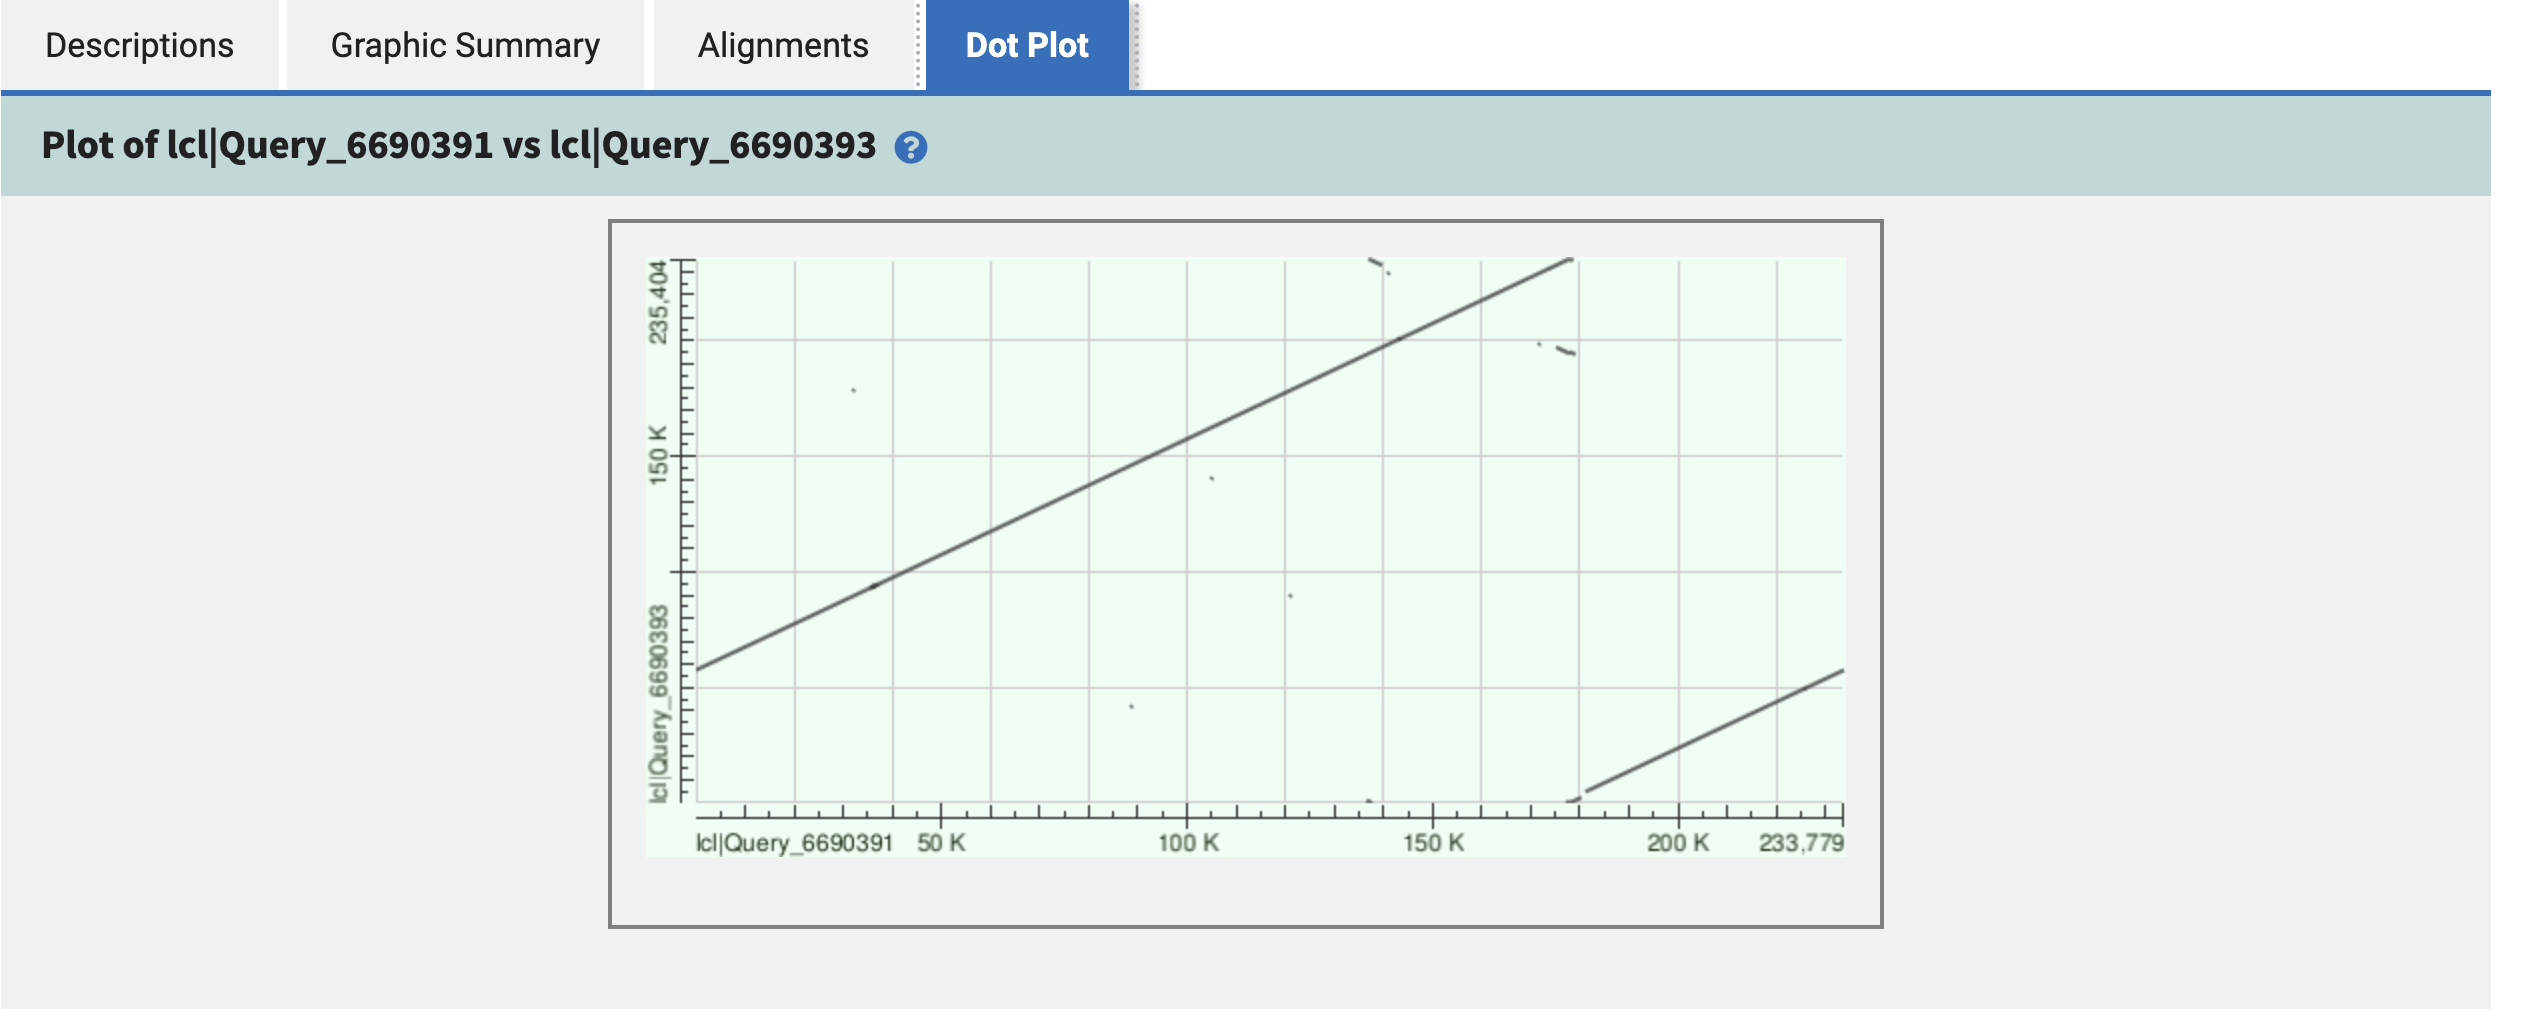

You want to look for where the end & start match to the Subject matches. It's a nice visualization way to investigate this, yet not detailed enough to get the actual number you need.

So now I'll need to use that information to rotate the Plasmidsaurus sequenced DNA to match my favorite BAC. **And after that step the linear arrangement of the two will better match.**

Plasmidsaurus suggest using [dnaapler](https://github.com/gbouras13/dnaapler) for this rotation, see ['Whole Genome Technical Documentation'](https://plasmidsaurus.com/technical-documentation/genome).  
I have a simpler script that I previosuly developed for this adjustment step that I am going to use here, and I suggest you use it as well.   
This notebook will step through doing that.

We'll need the script and the next line will do that in a way that will work at most places.

Note that if you were using a typical full Python kernel, you could simply use the following to do that:

```shell
!curl -OL https://raw.githubusercontent.com/fomightez/sequencework/refs/heads/master/AdjustFASTA_or_FASTQ/permute_seq_within_FASTA_an_amount.py
```

However, this notebook has been written to work in the most places and so the next cell uses a way that will work in both typical Python kernels and JupyterLite.

In [1]:
import requests
def fetch_github_file_using_requests(the_url):
    """
    Take a url for a raw GitHub file and return the file content using GitHub's CORS-enabled REST API endpoint
    """
    response = requests.get(the_url)
    response.raise_for_status()  # Raise an exception for non-200 status codes
    return response.text
url="https://raw.githubusercontent.com/fomightez/sequencework/refs/heads/master/AdjustFASTA_or_FASTQ/permute_seq_within_FASTA_an_amount.py"
file_content_string = fetch_github_file_using_requests(url)
with open(url.rsplit("/", 1)[-1], 'w', encoding='utf-8') as output_file:
    output_file.write(file_content_string)

One minor last preparation step.  
I named the `holy_toledo_mock_Plasmidsaurus_result.fa` to make it clear it was for the example.  
Let's rename it something more general so this notebook is easier to adapt for actual data later:

In [2]:
!cp holy_toledo_mock_Plasmidsaurus_result.fa plasmidsaurus_result.fasta

-----------------------------

With preparation steps complete, we are read to run the script, indicating the input sequence to use.   
And importantly, the number of positions to rotate the sequence.

In [3]:
%run permute_seq_within_FASTA_an_amount.py plasmidsaurus_result.fasta moot 177897

None


Single sequence with id of 'example_result' provided in the sequence file.
It will be permuted.

The file plasmidsaurus_result_permuted.fa with the sequence start permuted to position 177897 has been generated.

(Disregard the `None` on the first line. It is simply a side-effect of being able to conveniently use this script in ways other than the command line.)

Note from that example you can use 'moot' or any other word in that position if your input FASTA-formatted file is a single sequence. For a multi-sequence FASTA-formatted file, you'd specify the sequence identifier there. If you want to more about that, or using that script in general, see ['demonstration of permute_seq_within_FASTA_an_amount.py script' notebook here](https://github.com/fomightez/sequencework/blob/master/AdjustFASTA_or_FASTQ/demo%20permute_seq_within_FASTA_an_amount.ipynb).

## Align using MAFFT (or your favorite global aligner that can handle the length necessary)

BLAST was useful for doing the initial characterization verse the standard sequence. However, now we have things rotated(permuted) so the Plasmidsaurus result for the derivative sequence and the basis sequence should match up better along the full length of the two sequences. (Or at least the majority depending how much is different between your 'standard sequence' and the derived one you have.)  
The `L` in 'BLAST' stands for 'Local'. So this isn't the tool we want for matching up along the length of the two sequences. We want a 'global' alignment for this next step.

MAFFT is an aligner that can do such global alignments.

Luckily, [MAFFT's online, in-browser offering](https://mafft.cbrc.jp/alignment/server/) (presently  MAFFT version 7) allows long sequences, and so MAFFT can be used conveniently used for 'Huge Plasmids'/BACs without need for installing things or using command line-based software for this step.

[MAFFT's online, in-browser offering](https://mafft.cbrc.jp/alignment/server/) takes as input multi-sequence FASTA data. So we'll concatenate the plasmidsaurus result followed by the standard sequence into one `.fasta` file.

You'll ideally want to put your rotated Plasmidsaurus result first and then the standard on which it is more-or-less based. This will result in the alignment having the standard one on the bottom in the produced output.

In [4]:
!cat plasmidsaurus_result_permuted.fa HCMV_Toledo_wild-type.fasta > combined_for_MAFFT.fasta

You'll want to right-click on that file in the file browser pane in the left panel and 'Download' it.  
With that input file in hand, you are set to go do the alignment using [MAFFT's online, in-browser offering](https://mafft.cbrc.jp/alignment/server/).
The [MAFFT's online, in-browser offering](https://mafft.cbrc.jp/alignment/server/)  has an upload option below the 'Input' box. Look for `upload a plain text file` and choose the concatenated file on your system to upload.

Here's the details of the choices you want to make in MAFFT and how to collect the output....

You can choose to get notified if you don't want to wait right now. This can be useful for tracking the data, too. (It will remain available for a few days.)

For 'Strategy', use the 'Auto' setting (specifically, `Auto (FFT-NS-1, FFT-NS-2, FFT-NS-i or L-INS-i; depends on data size)`).  

And under 'Align unrelated segments, too?' toggle it to `Leave gappy regions` . 

Then click submit.

Two sequences of around 230 kb should take several minutes.

I note on the running page, you see `--thread 8` — and so it's using 8 threads on their cluster, so that, along with FFT, see below, is proably why it is reasonably fast with two long, very similar sequences.

**When you have your results...**

The result will come up and be shown to you at first in CLUSTAL format. Unintuitively, to download this version for use in upcoming steps, you'll need to click on some text near the top of that page.

Click on link in upper top left, just to the right of left navigation bar for 'Clustal format' to download the alignment in that format. I'd suggest naming it something meaningfull.    
(You may want to grab the FASTA format while at it? That link is to the right.)

**The `.aln` file MAFFT produces is provided here as `MAFFTclustal_output_permutedVStoledo.aln` so that the next steps will work.** (If you are doing this with your own data, after you download it from MAFFT, you have to drag-and-drop the file from your local machine into the file browser panel you see on the left.)

(Note if you use a different tool to produce the global alignment of the two sequences, you'll want CLUSTAL-formatted output in order to continue on with the next step as written here. There are several utilities that may help you convert appropriately, if necessary.)

## Add numbering to the alignment

That alignment has a lot of useful information; however, comparing it to things, such as the numbering in annotated FEATURES, is made difficult at this time because this CLUSTAL-formatted alignment has no numbering.

```text
CLUSTAL format alignment by MAFFT (v7.511)


example_re ccattccgggccgtgtgctgggtccccgaggggcgggggggtgtttttagcgggggggtg
GU937742.2 ccattccgggccgtgtgctgggtccccgaggggcgggggggtgtttttagcgggggggtg
           ************************************************************

example_re aaatttggagtcttggagccgcgtgtgctgtggaggacggtgacggtggtaagagtgtgc
GU937742.2 aaatttggagtcttggagccgcgtgtgctgtggaggacggtgacggtggtaagagtgtgc
           ************************************************************

example_re tgcggtgcggttgggacggcggcggcgaataaaagcggcgtgcggcgcgcacggcgaaaa
GU937742.2 tgcggtgcggttgggacggcggcggcgaataaaagcggcgtgcggcgcgcacggcgaaaa
           ************************************************************

example_re gcagacgcgcgtctgtgttgtgtgtctttgaccgcggcggaacacacgcggaaaagcgag
GU937742.2 gcagacgcgcgtctgtgttgtgtgtctttgaccgcggcggaacacacgcggaaaagcgag
           ************************************************************

example_re tcccaggggacacacgacgagcgagtcccagggggggacgacgacggccagggacgcgga
GU937742.2 tcccaggggacacacgacgagcgagtcccagggggggacgacgacggccagggacgcgga
           ************************************************************
```
                                                            

I suggest using another utility script I have developed to add the positions for each line to each of the two sequences. I suggest using [my script `add_pairwise_numbering_to_clustal_pair_matched_output.py](). 
Running this next cell will get that script:

In [5]:
import requests
def fetch_github_file_using_requests(the_url):
    """
    Take a url for a raw GitHub file and return the file content using GitHub's CORS-enabled REST API endpoint
    """
    response = requests.get(the_url)
    response.raise_for_status()  # Raise an exception for non-200 status codes
    return response.text
url="https://raw.githubusercontent.com/fomightez/sequencework/refs/heads/master/alignment-utilities/add_pairwise_numbering_to_clustal_pair_matched_output.py"
file_content_string = fetch_github_file_using_requests(url)
with open(url.rsplit("/", 1)[-1], 'w', encoding='utf-8') as output_file:
    output_file.write(file_content_string)

Now that we have the script, we can run it by pointing it at the CLUSTAL-formatted alignment, like this:

In [6]:
%run add_pairwise_numbering_to_clustal_pair_matched_output.py MAFFTclustal_output_permutedVStoledo.aln

Alignment read...
Sequence 1 (top): 'example_re'
Sequence 2 (bottom): 'GU937742.2'...
Annotated alignment saved to 'MAFFTclustal_output_permutedVStoledo_PAIRWISE_NUMBERED.aln'.

Let's look at the first few lines and see how this modified version of the alignment is more informative than above:

In [7]:
!head -33 MAFFTclustal_output_permutedVStoledo_PAIRWISE_NUMBERED.aln

CLUSTAL format alignment by MAFFT (v7.511)


           1                                                         60
example_re ccattccgggccgtgtgctgggtccccgaggggcgggggggtgtttttagcgggggggtg
           ************************************************************
GU937742.2 ccattccgggccgtgtgctgggtccccgaggggcgggggggtgtttttagcgggggggtg
           1                                                         60

           61                                                       120
example_re aaatttggagtcttggagccgcgtgtgctgtggaggacggtgacggtggtaagagtgtgc
           ************************************************************
GU937742.2 aaatttggagtcttggagccgcgtgtgctgtggaggacggtgacggtggtaagagtgtgc
           61                                                       120

           121                                                      180
example_re tgcggtgcggttgggacggcggcggcgaataaaagcggcgtgcggcgcgcacggcgaaaa
           ************************************************************
GU937742.2 tgcggt

You can see that now we know at which position we are in for each sequence.  
For this part it, really doesn't help us much but later we see things like ....

```text
           2341                                                    2400
example_re acagaccacggacacggcaaatgcatgcaaacttctcatttattgtgtctactactctgt
           ************************************************************
GU937742.2 acagaccacggacacggcaaatgcatgcaaacttctcatttattgtgtctactactctgt
           2341                                                    2400

           2401                                                    2424
example_re gttgctacagggagtgaagagggt------------------------------------
           *******************.****
GU937742.2 gttgctacagggagtgaagggggtgaaggcaaagaaaaaaaaaaggaacaaaataataga
           2401                                                    2460
           
```

That's because the GFP has replaced the non-coding RNA *RNA2.7* locus in the example Plasmidsaurus result sequence, and in the Toledo strain genome (used as standard here) *RNA2.7* spans 2362 - 4848, see [FEATURES here](https://www.ncbi.nlm.nih.gov/nuccore/GU937742) and look for `/gene="RNA2.7"`. As a result things with the sequence used here stops matching shortly after 2400 bp in the alignment.

Indeed, the other end looks even cleaner where the matching of the mock Plasmidsaurus results to the standard strain picks back up near postion 4848bp of the Toledo strain in the alignment where the numbers have been added:

```text
example_re ----------------gccc----------------------------------------
                           ****
GU937742.2 accagccggccgattcgcccgccggggcttctggagaacgccggggcagcagcgatctgg
           4786                                                    4845

           3240                                                    3299
example_re ggaagctgctaaacccctgcgtttttatatggtagctctgccgagcgcgggctgacgcgt
           ******.*****************************************************
GU937742.2 ggaagccgctaaacccctgcgtttttatatggtagctctgccgagcgcgggctgacgcgt
           4846                                                    4905

           3300                                                    3359
example_re tgggtaagcggaaagacgtgtgtgacgaaaaggggtcccatggtatttcacgtgacgatg
           **.*********************************************************
GU937742.2 tgagtaagcggaaagacgtgtgtgacgaaaaggggtcccatggtatttcacgtgacgatg
           4906                                                    4965

           3360                                                    3419
example_re aggagatacggtttggagcacatacggtttagaaaaagggagttgtcgtgacaagggctg
           *******.****************************************************
GU937742.2 aggagatgcggtttggagcacatacggtttagaaaaagggagttgtcgtgacaagggctg
           4966                                                    5025

```



This sets us up to discuss how you would assign additional sequences if you have an idea about what may have been added.  
For the sake of demonstration, let's suppose I didn't just share with you that `RNA2.7` has been replaced with GFP...  

You may be wondering what is accounting for the roughly 820 bp (~3240 - ~2420) that is where `RNA2.7` has been deleted and the global alignment shows a  substantial gap region?  
The next section will step through a simple example where the gaps in the alignment that don't match the standard sequence are assigned.  
You may have a much more complex scenario; however, that just means more iterations of the illustrated steps.

### Account for the 'extras'

I've assembled a group of common reporter genes,elements, & tags, i.e., fluorescent markers and related elements, tags, & markers, in the directory `reportersNtagsNparts` here.  
It can be useful to have such a collection and then compare them to your 'Huge Plasmid'/BAC to them to tell what may have been added beyond the standard. Or if you already have an inkling of what differences should be involved. You can easily do a pairwise BLAST comparison at the DNA level, as was discussed in the first step above to get the number of basepairs to rotate the received sequence.

Specifically for GFP, I'm using the 6787 bp plasmid [pCXGFP-1_](https://www.ncbi.nlm.nih.gov/nuccore/AB281497.1).

If you use BLAST to do a pairwise alignment of the permuted demo sequence with that vector, then you see:

Top Alignment result from BLAST:

```text
Range 1: 2988 to 3728 
Alignment statistics for match #1
Score	Expect	Identities	Gaps	Strand
1337 bits(1482)	0.0	741/741(100%)	0/741(0%)	Plus/Minus
Query  2458  CTTTACTTGTACAGCTCGTCCATGCCGAGAGTGATCCCGGCGGCGGTCACGAACTCCAGC  2517
             ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
Sbjct  3728  CTTTACTTGTACAGCTCGTCCATGCCGAGAGTGATCCCGGCGGCGGTCACGAACTCCAGC  3669

Query  2518  AGGACCATGTGATCGCGCTTCTCGTTGGGGTCTTTGCTCAGGGCGGACTGGGTGCTCAGG  2577
             ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
Sbjct  3668  AGGACCATGTGATCGCGCTTCTCGTTGGGGTCTTTGCTCAGGGCGGACTGGGTGCTCAGG  3609

Query  2578  TAGTGGTTGTCGGGCAGCAGCACGGGGCCGTCGCCGATGGGGGTGTTCTGCTGGTAGTGG  2637
             ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
Sbjct  3608  TAGTGGTTGTCGGGCAGCAGCACGGGGCCGTCGCCGATGGGGGTGTTCTGCTGGTAGTGG  3549

Query  2638  TCGGCGAGCTGCACGCTGCCGTCCTCGATGTTGTGGCGGATCTTGAAGTTCACCTTGATG  2697
             ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
Sbjct  3548  TCGGCGAGCTGCACGCTGCCGTCCTCGATGTTGTGGCGGATCTTGAAGTTCACCTTGATG  3489

Query  2698  CCGTTCTTCTGCTTGTCGGCCATGATATAGACGTTGTGGCTGTTGTAGTTGTACTCCAGC  2757
             ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
Sbjct  3488  CCGTTCTTCTGCTTGTCGGCCATGATATAGACGTTGTGGCTGTTGTAGTTGTACTCCAGC  3429

Query  2758  TTGTGCCCCAGGATGTTGCCGTCCTCCTTGAAGTCGATGCCCTTCAGCTCGATGCGGTTC  2817
             ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
Sbjct  3428  TTGTGCCCCAGGATGTTGCCGTCCTCCTTGAAGTCGATGCCCTTCAGCTCGATGCGGTTC  3369

Query  2818  ACCAGGGTGTCGCCCTCGAACTTCACCTCGGCGCGGGTCTTGTAGTTGCCGTCGTCCTTG  2877
             ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
Sbjct  3368  ACCAGGGTGTCGCCCTCGAACTTCACCTCGGCGCGGGTCTTGTAGTTGCCGTCGTCCTTG  3309

Query  2878  AAGAAGATGGTGCGCTCCTGGACGTAGCCTTCGGGCATGGCGGACTTGAAGAAGTCGTGC  2937
             ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
Sbjct  3308  AAGAAGATGGTGCGCTCCTGGACGTAGCCTTCGGGCATGGCGGACTTGAAGAAGTCGTGC  3249

Query  2938  TGCTTCATGTGGTCGGGGTAGCGGCTGAAGCACTGCACGCCGTAGGTCAGGGTGGTCACG  2997
             ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
Sbjct  3248  TGCTTCATGTGGTCGGGGTAGCGGCTGAAGCACTGCACGCCGTAGGTCAGGGTGGTCACG  3189

Query  2998  AGGGTGGGCCAGGGCACGGGCAGCTTGCCGGTGGTGCAGATGAACTTCAGGGTCAGCTTG  3057
             ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
Sbjct  3188  AGGGTGGGCCAGGGCACGGGCAGCTTGCCGGTGGTGCAGATGAACTTCAGGGTCAGCTTG  3129

Query  3058  CCGTAGGTGGCATCGCCCTCGCCCTCGCCGGACACGCTGAACTTGTGGCCGTTTACGTCG  3117
             ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
Sbjct  3128  CCGTAGGTGGCATCGCCCTCGCCCTCGCCGGACACGCTGAACTTGTGGCCGTTTACGTCG  3069

Query  3118  CCGTCCAGCTCGACCAGGATGGGCACCACCCCGGTGAACAGCTCCTCGCCCTTGCTCACC  3177
             ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
Sbjct  3068  CCGTCCAGCTCGACCAGGATGGGCACCACCCCGGTGAACAGCTCCTCGCCCTTGCTCACC  3009

Query  3178  ATGGTGGCGACCGGTGGATCC  3198
             |||||||||||||||||||||
Sbjct  3008  ATGGTGGCGACCGGTGGATCC  2988
```



There in the FEATURES section of [pCXGFP-1](https://www.ncbi.nlm.nih.gov/nuccore/AB281497.1), it shows this for GFP:

```text
     gene            3007..3726
                     /gene="EGFP"
     CDS             3007..3726
                     /gene="EGFP"
                     /codon_start=1
                     /transl_table=11
                     /product="enhanced green fluorescent protein"
                     /protein_id="BAF36707.1"
                     /translation="MVSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLT
                     LKFICTTGKLPVPWPTLVTTLTYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFK
                     DDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKN
                     GIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDH
                     MVLLEFVTAAGITLGMDELYK"
```

So 2460 to 3179 of the permuted mock Plasmidsaurus result can be assigned as being a perfect match to what is encoded as 'EGFP (enhanced green fluorescent protein)'.  
You may have a much more complex scenario with other markers and combinations of elemetns for your own sequences. That will just mean more iterations of the illustrated steps.

If you Plasmidsaurus result possibly shows some E. coli insertion elements:  
see [ISFinder](https://www-is.biotoul.fr/index.php)
(because you may see match to sequences repeated in E. coli in your 'Huge Plasmid'/BAC).
And if the genomes you get matched to may not have the particular element annotated, ISFinder can still tell you which one it is.
ISFinder has a BLAST option that searches it against its database to help you see which one it is closest in relation.



----------

Enjoy!
